# Lab. 3: Momentum I

In this lab we will explore the signal research proccess with the classic Jegadeesh and Titman momentum signal.

We will explore:
- How to compute signals with point in time compliance in mind.
- The need to filter out low priced securities.
- How to create decile and spread portfolios.
- Strategy performance metrics.

## Imports

In [1]:
import sf_quant.data as sfd
import polars as pl
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/home/bwaits/Research/sf-quant-labs/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-09-06 14:48:42,744	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


## Data

We will be looking at our investment universe from 1996 to 2024.

This should take around 10 seconds to run.

In [2]:
start = dt.date(1996, 1, 1)
end = dt.date(2024, 12, 31)

columns = [
    'date',
    'barrid',
    'ticker',
    'price',
    'return',
    'market_cap'
]

data = sfd.load_assets(
    start=start,
    end=end,
    in_universe=True,
    columns=columns
)

data

date,barrid,ticker,price,return,market_cap
date,str,str,f64,f64,f64
2013-07-31,"""USA06Z1""","""MDXG""",6.26,-0.1595,6.006157e8
2013-08-01,"""USA06Z1""","""MDXG""",6.32,0.9585,6.0865392e8
2013-08-02,"""USA06Z1""","""MDXG""",6.31,-0.1582,6.0769086e8
2013-08-05,"""USA06Z1""","""MDXG""",6.45,2.2187,6.211737e8
2013-08-06,"""USA06Z1""","""MDXG""",6.29,-2.4806,6.0576474e8
…,…,…,…,…,…
2024-12-24,"""USBQOR1""","""ECG""",70.58,2.5872,3.5976e9
2024-12-26,"""USBQOR1""","""ECG""",73.61,4.293,3.7521e9
2024-12-27,"""USBQOR1""","""ECG""",69.85,-5.108,3.5604e9


## Compute the Momentum Signal

## Instructions

- Compute momentum for each security and date as the rolling 230 day return (you can just use log returns here).
- Shift the momentum signal 22 days. This will results in the 11 month return from t-12 to t-2.

In [3]:
def task_compute_momentum(data: pl.DataFrame) -> pl.DataFrame:
    """
    Compute the t_12 to t_2 momentum signal for each secrutiy and date combination.
    
    Args:
        data (pl.DataFrame): Data frame containing date, barrid, price, and return columns.
    
    Returns:
        pl.DataFrame: Data frame with columns date, barrid, price, return, and momentum columns.
    """
    
    #convert returns to decimal space
    data = (
        data.with_columns(
            pl.col('return').truediv(100).alias('return')))
    
    momentum = (
        data.with_columns(
            pl.col('return')
            .log1p()
            .rolling_sum(window_size=230)
            .shift(22)
            .over('barrid')
            .alias('mom')
        )
        .sort(['barrid', 'date'])
    )
    return momentum

momentum = task_compute_momentum(data)

momentum

date,barrid,ticker,price,return,market_cap,mom
date,str,str,f64,f64,f64,f64
2013-07-31,"""USA06Z1""","""MDXG""",6.26,-0.001595,6.006157e8,null
2013-08-01,"""USA06Z1""","""MDXG""",6.32,0.009585,6.0865392e8,null
2013-08-02,"""USA06Z1""","""MDXG""",6.31,-0.001582,6.0769086e8,null
2013-08-05,"""USA06Z1""","""MDXG""",6.45,0.022187,6.211737e8,null
2013-08-06,"""USA06Z1""","""MDXG""",6.29,-0.024806,6.0576474e8,null
…,…,…,…,…,…,…
2024-12-24,"""USBQOR1""","""ECG""",70.58,0.025872,3.5976e9,null
2024-12-26,"""USBQOR1""","""ECG""",73.61,0.04293,3.7521e9,null
2024-12-27,"""USBQOR1""","""ECG""",69.85,-0.05108,3.5604e9,null


## Price and Momentum Filter

When doing backtesting strategies it's helpful to drop securities with a price below $5.

- Create a variable price_lag that is the previous days price for each security.
- Filter securities to ones with a lagged price greater than 5.
- Drop null momentum values since we won't trade securities where we don't have a signal.

In [4]:
def task_price_filter(momentum: pl.DataFrame) -> pl.DataFrame:
    """
    Filter the universe to lagged price greater than 5 and non-null momentum.
    
    Args:
        momentum (pl.DataFrame): Data frame with columns date, barrid, price, return, and momentum columns.
    
    Returns:
        pl.DataFrame: Data frame with columns date, barrid, price, return, and momentum columns.
    """
    momentum = momentum.with_columns(
        pl.col('price').shift(1).over('barrid').alias('price_lag'))
    
    momentum = momentum.filter((pl.col('price_lag') >= (5))).drop_nulls('mom')
    
    return momentum

price_filter = task_price_filter(momentum)

price_filter

date,barrid,ticker,price,return,market_cap,mom,price_lag
date,str,str,f64,f64,f64,f64,f64
2014-07-30,"""USA06Z1""","""MDXG""",7.1,0.009957,7.410696e8,0.101525,7.03
2014-07-31,"""USA06Z1""","""MDXG""",6.91,-0.026761,7.2123816e8,0.124505,7.1
2014-08-01,"""USA06Z1""","""MDXG""",6.81,-0.014472,7.1080056e8,0.167176,6.91
2014-08-04,"""USA06Z1""","""MDXG""",7.08,0.039648,7.3898208e8,0.159344,6.81
2014-08-05,"""USA06Z1""","""MDXG""",7.05,-0.004237,7.358508e8,0.14279,7.08
…,…,…,…,…,…,…,…
2024-12-27,"""USBPJV1""","""NLOP""",30.81,-0.019414,4.5553e8,0.527437,31.42
2024-12-30,"""USBPJV1""","""NLOP""",31.08,0.008763,4.5952e8,0.522813,30.81
2024-12-31,"""USBPJV1""","""NLOP""",31.21,0.004183,4.6144e8,0.552793,31.08


## Create Decile Portfolios

### Instructions

- For each date divide all securities into 10 deciles based on their momentum score. The highest momentum securities should be in bin 9 and the lowest momentum securities should be in bin 0. The `.qcut()` expression will be helpful here.


In [5]:
def task_momentum_bins(price_filter: pl.DataFrame) -> pl.DataFrame:
    """
    Bin the securities into deciles for each date by momentum.
    
    Args:
        price_filter (pl.DataFrame): Data frame with columns date, barrid, price, return, and momentum columns.
    
    Returns:
        pl.DataFrame: Data frame with columns date, barrid, price, return, momentum and bin columns.
    """
    labels = [str(i) for i in range(10)]
    
    momentum_bins = (
        price_filter.with_columns(
            pl.col('mom')
            .qcut(10, labels=labels)
            .over('date')
            .alias('bin')
        )
        .sort(['barrid', 'date'])
    )
    return momentum_bins

momentum_bins = task_momentum_bins(price_filter)

momentum_bins

date,barrid,ticker,price,return,market_cap,mom,price_lag,bin
date,str,str,f64,f64,f64,f64,f64,cat
2014-07-30,"""USA06Z1""","""MDXG""",7.1,0.009957,7.410696e8,0.101525,7.03,"""4"""
2014-07-31,"""USA06Z1""","""MDXG""",6.91,-0.026761,7.2123816e8,0.124505,7.1,"""4"""
2014-08-01,"""USA06Z1""","""MDXG""",6.81,-0.014472,7.1080056e8,0.167176,6.91,"""5"""
2014-08-04,"""USA06Z1""","""MDXG""",7.08,0.039648,7.3898208e8,0.159344,6.81,"""5"""
2014-08-05,"""USA06Z1""","""MDXG""",7.05,-0.004237,7.358508e8,0.14279,7.08,"""5"""
…,…,…,…,…,…,…,…,…
2024-12-27,"""USBPJV1""","""NLOP""",30.81,-0.019414,4.5553e8,0.527437,31.42,"""8"""
2024-12-30,"""USBPJV1""","""NLOP""",31.08,0.008763,4.5952e8,0.522813,30.81,"""8"""
2024-12-31,"""USBPJV1""","""NLOP""",31.21,0.004183,4.6144e8,0.552793,31.08,"""9"""


## Equal Weight Portfolios

For each date and bin combo compute the equal weight return.

### Instructions
- Use `.group_by()` to find the average return for each decile on each date.
- Pivot the data frame into index=date, columns=bins, and values=returns (`.pivot()`)
- Compute the spread portfolio as the return of bin 9 minus the return of bin 0

In [7]:
def task_equal_weight_portfolios(momentum_bins: pl.DataFrame) -> pl.DataFrame:
    """
    Compute the equal weight return for each bin on each date.
    
    Args:
        momentum_bins (pl.DataFrame): Data frame with columns date, barrid, price, return, momentum, and bin columns.
    
    Returns:
        pl.DataFrame: Data frame with date as the index, bins as the columns, and returns as the values.
    """
    ew_port = (
        momentum_bins.group_by(['date', 'bin'])
        .agg(pl.col('return').mean())
        .pivot(on='bin', index='date', values='return')
        .with_columns((pl.col('9') - pl.col('0')).alias('spread'))
        .sort('date')
    )
    
    return ew_port

momentum_portfolios = task_equal_weight_portfolios(momentum_bins)

momentum_portfolios

date,7,3,5,6,8,9,1,2,0,4,spread
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1996-12-27,0.003678,0.004501,0.005725,0.002967,0.003605,-0.000914,0.003037,0.003343,-0.001029,0.004186,0.000114
1996-12-30,0.002099,0.000977,0.003499,0.002475,0.004764,0.000182,-0.002342,-0.001762,-0.008296,0.003697,0.008478
1996-12-31,-0.001242,0.000311,0.001501,0.00415,-0.001541,0.004926,0.003765,0.000242,0.011733,0.000937,-0.006807
1997-01-02,-0.01102,-0.006915,-0.007483,-0.009344,-0.013618,-0.017719,-0.001642,-0.00488,0.007542,-0.006713,-0.025262
1997-01-03,0.009066,0.007823,0.006642,0.006741,0.010573,0.012844,0.013244,0.008231,0.018497,0.006031,-0.005653
…,…,…,…,…,…,…,…,…,…,…,…
2024-12-24,0.009136,0.007497,0.007974,0.008316,0.011663,0.013276,0.007633,0.008055,0.007357,0.007919,0.005919
2024-12-26,0.0053,0.006012,0.004141,0.003946,0.007306,0.010651,0.008819,0.006301,0.017455,0.003937,-0.006805
2024-12-27,-0.013104,-0.011024,-0.012319,-0.011748,-0.014801,-0.020485,-0.012441,-0.010328,-0.014529,-0.010892,-0.005956


## Portfolio Returns

Compute the cumulative returns of each bin.

### Instructions
- Use the `.unpivot()` method to put our data frame back into long format.
- Compute the cumulative log return.
- Put the return columns into percent space by multiplying by 100.

In [9]:
def task_cumulative_returns(momentum_portfolios: pl.DataFrame) -> pl.DataFrame:
    """
    Compute the equal weight return for each bin on each date.
    
    Args:
        momentum_portfolios (pl.DataFrame): Data frame with columns date, barrid, price, return, momentum, and bin columns.
    
    Returns:
        pl.DataFrame: Data frame with date, bin, return, and cumulative_log_return columns.
    """
    momentum_returns = (
        momentum_portfolios
        .unpivot(
            index="date",
            on=[str(i) for i in range(10)] + ["spread"],
            variable_name="bin",
            value_name="return"
        )
        .with_columns([
            (pl.col("return") * 100).alias("return_pct"),
            pl.col("return").log1p().cum_sum().alias("cum_log_return")
        ])
        .sort("date")
    )
    return momentum_returns

momentum_returns = task_cumulative_returns(momentum_portfolios)

momentum_returns

date,bin,return,return_pct,cum_log_return
date,str,f64,f64,f64
1996-12-27,"""0""",-0.001029,-0.102862,-0.001029
1996-12-27,"""1""",0.003037,0.303673,0.458313
1996-12-27,"""2""",0.003343,0.334264,2.361913
1996-12-27,"""3""",0.004501,0.450116,4.516874
1996-12-27,"""4""",0.004186,0.418648,7.400821
…,…,…,…,…
2024-12-31,"""6""",0.001817,0.181663,16.063572
2024-12-31,"""7""",0.000863,0.086263,19.378594
2024-12-31,"""8""",-0.000483,-0.048322,22.906613


## Performance Analysis

### Instructions
- Chart the cumulative log returns of the 10 decile portfolios and the spread portfolio.
- Create a table with average daily return (annualized), volatility (annualized), and sharpe ratio (annualized) for each portfolio.

In [13]:
momentum_portfolios

date,7,3,5,6,8,9,1,2,0,4,spread
date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1996-12-27,0.003678,0.004501,0.005725,0.002967,0.003605,-0.000914,0.003037,0.003343,-0.001029,0.004186,0.000114
1996-12-30,0.002099,0.000977,0.003499,0.002475,0.004764,0.000182,-0.002342,-0.001762,-0.008296,0.003697,0.008478
1996-12-31,-0.001242,0.000311,0.001501,0.00415,-0.001541,0.004926,0.003765,0.000242,0.011733,0.000937,-0.006807
1997-01-02,-0.01102,-0.006915,-0.007483,-0.009344,-0.013618,-0.017719,-0.001642,-0.00488,0.007542,-0.006713,-0.025262
1997-01-03,0.009066,0.007823,0.006642,0.006741,0.010573,0.012844,0.013244,0.008231,0.018497,0.006031,-0.005653
…,…,…,…,…,…,…,…,…,…,…,…
2024-12-24,0.009136,0.007497,0.007974,0.008316,0.011663,0.013276,0.007633,0.008055,0.007357,0.007919,0.005919
2024-12-26,0.0053,0.006012,0.004141,0.003946,0.007306,0.010651,0.008819,0.006301,0.017455,0.003937,-0.006805
2024-12-27,-0.013104,-0.011024,-0.012319,-0.011748,-0.014801,-0.020485,-0.012441,-0.010328,-0.014529,-0.010892,-0.005956


In [15]:
momentum_returns

date,bin,return,return_pct,cum_log_return
date,str,f64,f64,f64
1996-12-27,"""0""",-0.001029,-0.102862,-0.001029
1996-12-27,"""1""",0.003037,0.303673,0.458313
1996-12-27,"""2""",0.003343,0.334264,2.361913
1996-12-27,"""3""",0.004501,0.450116,4.516874
1996-12-27,"""4""",0.004186,0.418648,7.400821
…,…,…,…,…
2024-12-31,"""6""",0.001817,0.181663,16.063572
2024-12-31,"""7""",0.000863,0.086263,19.378594
2024-12-31,"""8""",-0.000483,-0.048322,22.906613


In [22]:

bins_labels = [str(i) for i in range(10)] + ["spread"]

# compute cumulative log returns for each portfolio column
momentum_portfolios_cum = (
    momentum_portfolios
    .with_columns([
        pl.col(c).log1p().cum_sum().alias(c) for c in bins_labels
    ])
    .select(["date"] + bins_labels)
    .sort("date")
)


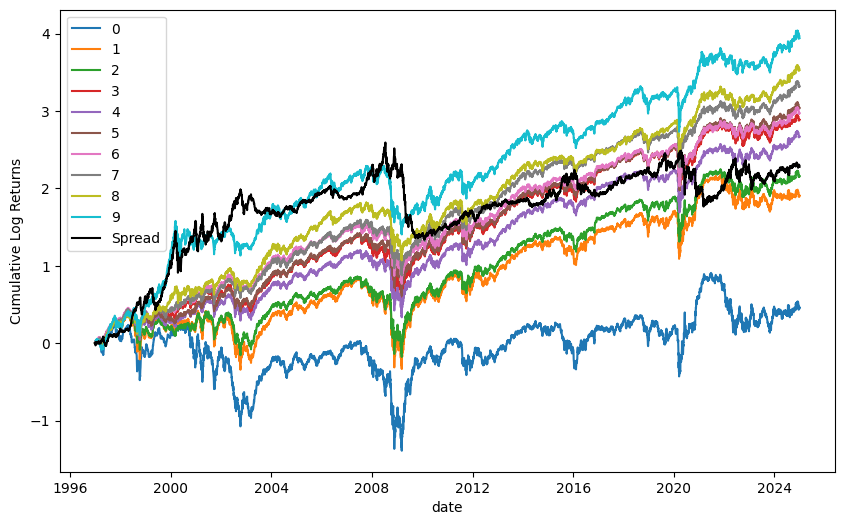

In [26]:
# TODO: Chart the cumulative log returns of each portfolio.

plt.figure(figsize=(10, 6))

labels = [str(i) for i in range(10)]
for label in labels:
    sns.lineplot(momentum_portfolios_cum, x='date', y=label, label=label)

sns.lineplot(momentum_portfolios_cum, x='date', y='spread', color = 'black', label='Spread')

plt.ylabel("Cumulative Log Returns")
plt.legend()

In [11]:
# TODO: Create a table of summary metrics
stats = (
    momentum_returns
    .group_by("bin")
    .agg([
        (pl.col("return").mean() * 252).alias("avg_return_ann"),
        (pl.col("return").std() * np.sqrt(252)).alias("vol_ann")
    ])
    .with_columns(
        (pl.col("avg_return_ann") / pl.col("vol_ann")).alias("sharpe_ann")
    )
    .sort("bin")
)

stats_df = stats.to_pandas()
stats_df

,bin,avg_return_ann,vol_ann,sharpe_ann
0,0,0.068540,0.323504,0.211869
1,1,0.102513,0.262424,0.390638
2,2,0.104798,0.235594,0.444825
3,3,0.127653,0.221143,0.577241
4,4,0.117307,0.209346,0.560350
5,5,0.129072,0.202600,0.637081
6,6,0.126037,0.199227,0.632627
7,7,0.138867,0.201271,0.689952
8,8,0.148935,0.212973,0.699311
9,9,0.175691,0.263080,0.667825
